In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image as PILImage

from src.config import OUTPUTS, IMG_SIZE, MLP_IMG_SIZE
from src.mlp import MLP
from src.cnn import CNN
from src.transfer import build_feature_extractor, build_fine_tuner
from src.data import get_transforms

# Cargar modelos
pca = joblib.load(OUTPUTS / "pca_mlp.joblib")

mlp_model = MLP(input_dim=pca.n_components_)
mlp_model.load_state_dict(torch.load(OUTPUTS / "mlp_best.pt", map_location="cpu"))
mlp_model.eval()

cnn_model = CNN()
cnn_model.load_state_dict(torch.load(OUTPUTS / "cnn_best.pt", map_location="cpu"))
cnn_model.eval()

fe_model = build_feature_extractor()
fe_model.load_state_dict(torch.load(OUTPUTS / "fe_best.pt", map_location="cpu"))
fe_model.eval()

ft_model = build_fine_tuner()
ft_model.load_state_dict(torch.load(OUTPUTS / "ft_best.pt", map_location="cpu"))
ft_model.eval()

print("Modelos cargados.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/lautarocaminoa/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:07<00:00, 14.2MB/s]


Modelos cargados.


# Predicción con Imagen Propia

Los cuatro modelos predicen si la imagen  en `ruta` es real o generada por IA.

Para mejores resultados se recomienda usar imágenes de **paisajes, naturaleza, arquitectura o arte**, que es el tipo de imágenes sobre el que fueron entrenados los modelos.

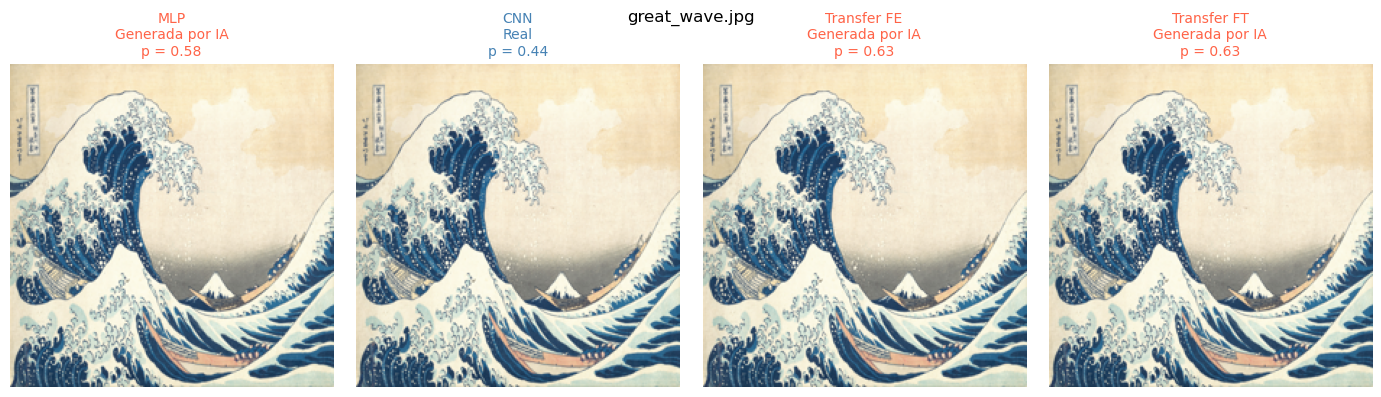

In [5]:
ruta = Path("imgs/great_wave.jpg")

with PILImage.open(ruta) as img:
    img_rgb = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))

x_cnn = get_transforms("val")(img_rgb).unsqueeze(0)

img_mlp = img_rgb.resize((MLP_IMG_SIZE, MLP_IMG_SIZE))
x_mlp = pca.transform(np.array(img_mlp, dtype=np.uint8).flatten().reshape(1, -1)).astype(np.float32)

with torch.no_grad():
    prob_mlp = mlp_model(torch.from_numpy(x_mlp)).sigmoid().item()
    prob_cnn = cnn_model(x_cnn).sigmoid().item()
    prob_fe = fe_model(x_cnn).sigmoid().item()
    prob_ft = ft_model(x_cnn).sigmoid().item()

nombres = ["MLP", "CNN", "Transfer FE", "Transfer FT"]
probs = [prob_mlp, prob_cnn, prob_fe, prob_ft]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, nombre, prob in zip(axes, nombres, probs):
    pred = "Generada por IA" if prob >= 0.5 else "Real"
    color = "tomato" if pred == "Generada por IA" else "steelblue"
    ax.imshow(img_rgb)
    ax.set_title(f"{nombre}\n{pred}\np = {prob:.2f}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle(ruta.name, fontsize=12)
plt.tight_layout()
plt.show()